In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score
 

In [104]:
df = pd.read_csv('student_performance_dirty.csv')

In [105]:
df.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Notes
0,7.0,99,Yes,9.0,1,91.0,excellent
1,4.0,82,No,4.0,2,65.0,review
2,8.0,51,Yes,7.0,2,45.0,review
3,5.0,52,Yes,5.0,2,36.0,excellent
4,7.0,75,No,8.0,5,66.0,review


In [106]:
df.isnull().sum()

Hours Studied                       1032
Previous Scores                        0
Extracurricular Activities             0
Sleep Hours                          496
Sample Question Papers Practiced       0
Performance Index                      0
Notes                                  0
dtype: int64

In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10005 entries, 0 to 10004
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     8973 non-null   float64
 1   Previous Scores                   10005 non-null  int64  
 2   Extracurricular Activities        10005 non-null  str    
 3   Sleep Hours                       9509 non-null   float64
 4   Sample Question Papers Practiced  10005 non-null  int64  
 5   Performance Index                 10005 non-null  float64
 6   Notes                             10005 non-null  str    
dtypes: float64(3), int64(2), str(2)
memory usage: 547.3 KB


In [108]:
df['Hours Studied'].value_counts()

Hours Studied
1.0    1025
7.0    1018
3.0    1012
6.0    1004
9.0    1003
8.0     984
5.0     981
2.0     979
4.0     967
Name: count, dtype: int64

In [109]:
mean_hours_studied = df['Hours Studied'].mean()
df['Hours Studied']= df['Hours Studied'].replace(np.nan,mean_hours_studied)

In [110]:
df['Sleep Hours']=df['Sleep Hours'].fillna(df['Sleep Hours'].mean())

In [111]:
df['Sleep Hours'].isnull().sum()

np.int64(0)

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10005 entries, 0 to 10004
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10005 non-null  float64
 1   Previous Scores                   10005 non-null  int64  
 2   Extracurricular Activities        10005 non-null  str    
 3   Sleep Hours                       10005 non-null  float64
 4   Sample Question Papers Practiced  10005 non-null  int64  
 5   Performance Index                 10005 non-null  float64
 6   Notes                             10005 non-null  str    
dtypes: float64(3), int64(2), str(2)
memory usage: 547.3 KB


In [115]:
activities = pd.get_dummies(df['Extracurricular Activities'],drop_first = True)

In [116]:
df = pd.concat([df,activities],  axis=1)

In [117]:
df.drop(columns='Extracurricular Activities',inplace = True)

In [118]:
df.head(5)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Notes,Yes
0,7.0,99,9.0,1,91.0,excellent,True
1,4.0,82,4.0,2,65.0,review,False
2,8.0,51,7.0,2,45.0,review,True
3,5.0,52,5.0,2,36.0,excellent,True
4,7.0,75,8.0,5,66.0,review,False


In [119]:
df = df[['Hours Studied','Previous Scores','Sleep Hours','Sample Question Papers Practiced','Yes','Notes','Performance Index']]

In [120]:
df = df.rename(columns={'Yes':'ExtraCurricular Activites'})

In [121]:
df.head(5)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,ExtraCurricular Activites,Notes,Performance Index
0,7.0,99,9.0,1,True,excellent,91.0
1,4.0,82,4.0,2,False,review,65.0
2,8.0,51,7.0,2,True,review,45.0
3,5.0,52,5.0,2,True,excellent,36.0
4,7.0,75,8.0,5,False,review,66.0


In [122]:
df.drop(columns='Notes',inplace = True)

<Axes: xlabel='Sleep Hours', ylabel='Performance Index'>

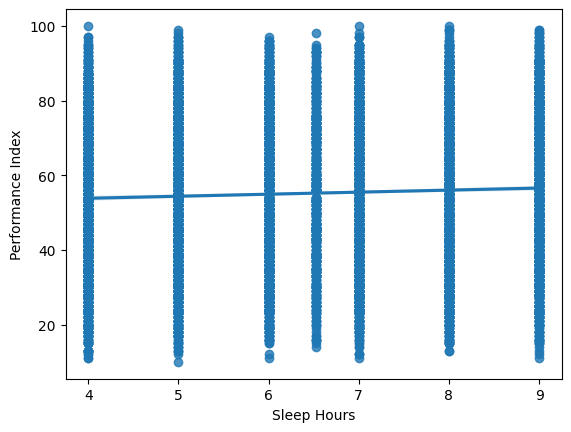

In [126]:
sns.regplot(x='Sleep Hours', y = 'Performance Index',data = df)

<Axes: xlabel='Hours Studied', ylabel='Performance Index'>

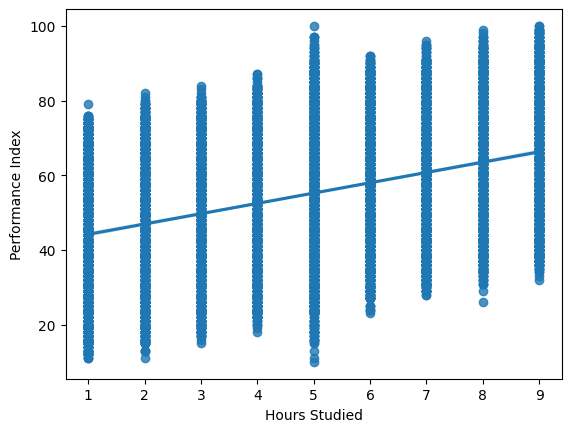

In [127]:
sns.regplot(x='Hours Studied', y = 'Performance Index',data = df)

<Axes: xlabel='Sample Question Papers Practiced', ylabel='Performance Index'>

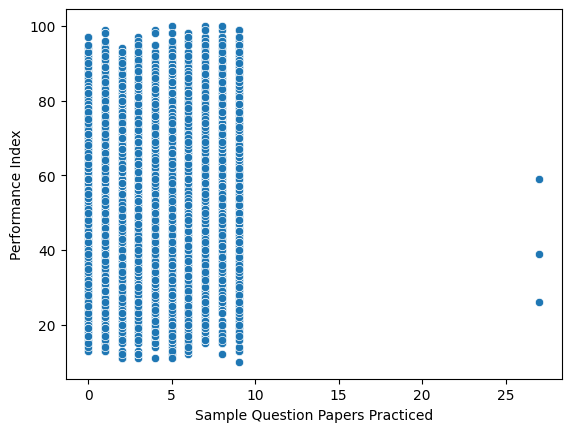

In [128]:
sns.scatterplot(x = 'Sample Question Papers Practiced',y = 'Performance Index',data = df)

<Axes: ylabel='Performance Index'>

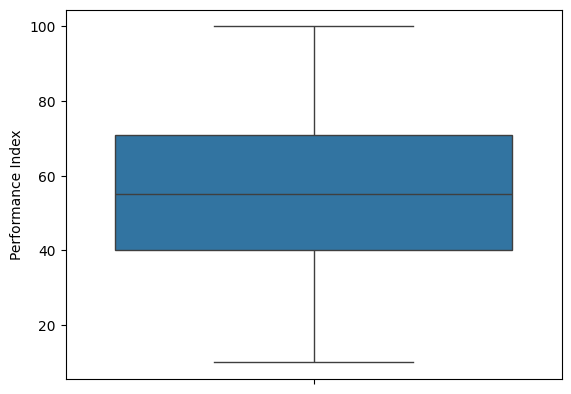

In [130]:
sns.boxplot(df['Performance Index'])

<Axes: ylabel='Sample Question Papers Practiced'>

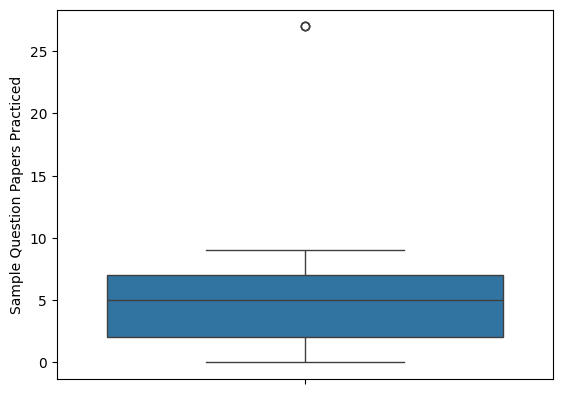

In [131]:
sns.boxplot(df['Sample Question Papers Practiced'])

<Axes: >

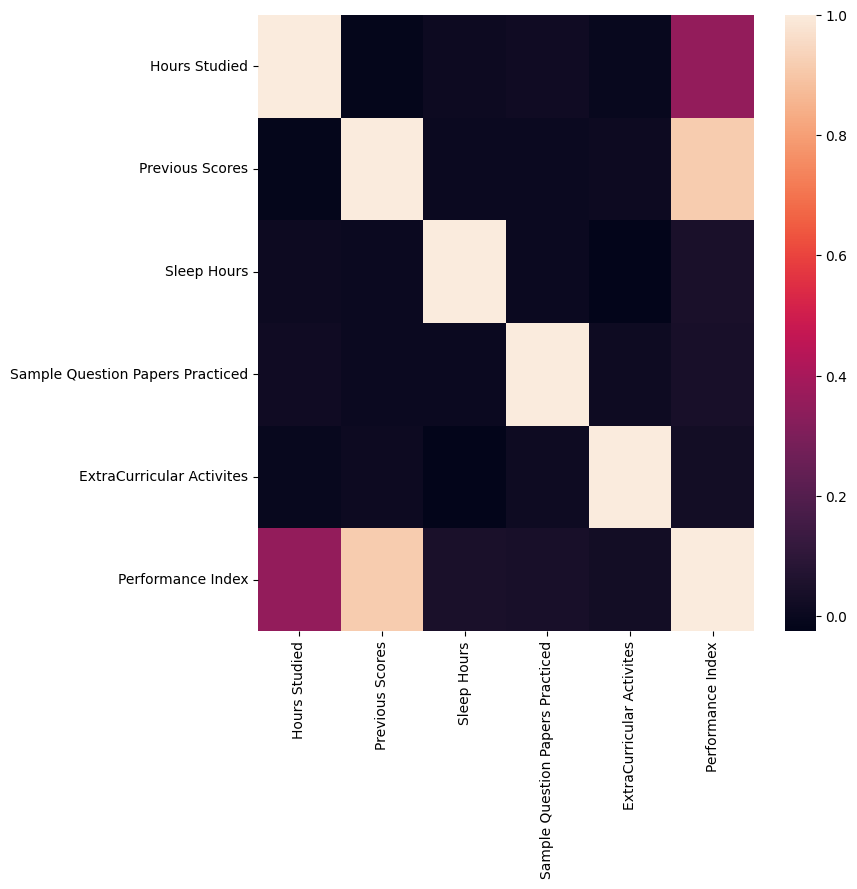

In [138]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr())

In [123]:
x = df.drop(columns='Performance Index')
y = df['Performance Index']
x_train , x_test ,  y_train , y_test = train_test_split(x , y ,  test_size=0.25,random_state=42)

In [124]:
print('shape of x train is: ',x_train.shape)
print('shape of x test is: ',x_test.shape)
print('shape of y train is: ',y_train.shape)
print('shape of y test is: ',y_test.shape)

shape of x train is:  (7503, 5)
shape of x test is:  (2502, 5)
shape of y train is:  (7503,)
shape of y test is:  (2502,)


In [125]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [139]:
pred = model.predict(x_test)

In [167]:
MAE = mean_absolute_error(y_test, pred)
print('your mean absolute error is: ',MAE)
print('YOUR MEAN SQUARE ERROR:',mean_squared_error(y_test,pred))
print('Your r2 score is: ',r2_score(y_test,pred))

your mean absolute error is:  2.1359086544477326
YOUR MEAN SQUARE ERROR: 9.740863754009775
Your r2 score is:  0.9734956562188041


In [170]:
perf_unseen = cross_val_score(
    model,
    x,
    y,
    cv = 5
)
print(perf_unseen.mean())

0.9738978528927547


In [148]:
comparissopn = pd.DataFrame(
    {
        'old':y_test,
        'Predicted':pred
    }
)

In [154]:
comparissopn.iloc[5,1]

np.float64(61.370229881520515)

In [173]:
# to check decision tree
parameters = {
    'max_depth':[1,2,3,5,7,8],
    'criterion':['squared_error','absolute_error','poisson']
}
grid_serarch = GridSearchCV(
    DecisionTreeRegressor(),
    parameters,
    cv = 5
)

grid_serarch.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [174]:
print('BEST VALUES ARE : ',grid_serarch.best_estimator_)

BEST VALUES ARE :  DecisionTreeRegressor(criterion='poisson', max_depth=8)


In [175]:
model2 = DecisionTreeRegressor(criterion='poisson',max_depth=8)
model2.fit(x_train,y_train)

y_hat = model2.predict(x_test)


In [176]:
MAE = mean_absolute_error(y_test, y_hat)
print('your mean absolute error is: ',MAE)
print('YOUR MEAN SQUARE ERROR:',mean_squared_error(y_test,y_hat))
print('r2 score: ',r2_score(y_test,y_hat))

your mean absolute error is:  2.5386873155052414
YOUR MEAN SQUARE ERROR: 12.464765143301088
r2 score:  0.9660840733580813


In [177]:
perf_unseen = cross_val_score(
    model2,
    x,
    y,
    cv = 5
)
print(perf_unseen.mean())

0.96687503034145
